# Micro-KDN Evaluation Notebook (Colab)

This notebook helps you evaluate model predictions from your implementation using the repository's evaluation logic.

## Recommended Colab runtime
- **Runtime type:** Python 3
- **Hardware accelerator:** **CPU** (recommended for evaluation-only workflows)
- If you also want to run inference in the same notebook, switch to **T4 GPU**.

In [1]:
from huggingface_hub import notebook_login

notebook_login()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


## 1) Clone (or pull) repo and install dependencies
Set `REPO_URL` to your fork/repo URL. The cell will clone if missing, otherwise pull latest changes.

In [2]:
REPO_URL = "https://github.com/Surya-Prasad/slm-kdn.git"
REPO_DIR = "/content/slm-kdn"

from pathlib import Path
import os

if Path(REPO_DIR).exists():
    %cd $REPO_DIR
    !git pull
else:
    !git clone $REPO_URL $REPO_DIR
    %cd $REPO_DIR

!python -m pip install --upgrade pip
!pip install -r requirements.txt
!pip install matplotlib pandas seaborn

Cloning into '/content/slm-kdn'...
remote: Enumerating objects: 71, done.
remote: Counting objects: 100% (71/71), done.
remote: Compressing objects: 100% (43/43), done.
remote: Total 71 (delta 31), reused 63 (delta 27), pack-reused 0 (from 0)
Receiving objects: 100% (71/71), 89.41 KiB | 14.90 MiB/s, done.
Resolving deltas: 100% (31/31), done.
/content/slm-kdn
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 83.2 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 162.2 MB/s  0:00:00
  Created wheel for rouge-score: filename=rouge_score-0.1.2-py3-none-any.whl size=24988 sha256=36d2b7ce7e650bcc09e057469b437f323380aeec431c6eb8a6433fd97455a1a2
  Stored in directory: /root/.cache/pip/wheels

In [3]:
%%writefile src/load_dataset.py
import argparse, re
from datasets import load_dataset, DatasetDict
from sklearn.model_selection import train_test_split
from utils import ensure_dir, load_config, write_jsonl

def infer_columns(columns):
    lc = {c.lower(): c for c in columns}
    # Included the fix for 'question' and 'answer' mapping!
    intent = next((lc[k] for k in lc if "intent" in k or "query" in k or "question" in k), None)
    cmd = next((lc[k] for k in lc if "command" in k or "config" in k or "label" in k or "answer" in k), None)
    context = next((lc[k] for k in lc if "context" in k or "description" in k or "desc" in k), None)
    return intent, context, cmd

def map_record(row, intent_col, context_col, cmd_col):
    raw_cmd = str(row.get(cmd_col, "")).strip()

    # regex to strip "Use the following command in the [X] mode:"
    clean_cmd = re.sub(r"Use the following command.*?:\s*", "", raw_cmd, flags=re.IGNORECASE | re.DOTALL)
    # Remove any markdown backticks that might be lingering
    clean_cmd = clean_cmd.replace('`', '').strip()

    return {
        "intent": str(row.get(intent_col, "")).strip(),
        "context": str(row.get(context_col, "")).strip() if context_col else "",
        "target_command": clean_cmd,
        "category": str(row.get("category", "")),
    }

def main(args):
    cfg = load_config(args.config)
    ds = load_dataset(cfg["data"]["dataset_name"])
    if not isinstance(ds, DatasetDict):
        ds = DatasetDict({"train": ds})

    sample_split = next(iter(ds.keys()))
    intent_col, context_col, cmd_col = infer_columns(ds[sample_split].column_names)

    mapped = []
    for split_name in ds.keys():
        for row in ds[split_name]:
            mapped.append(map_record(row, intent_col, context_col, cmd_col))

    filtered = [r for r in mapped if r["intent"] and r["target_command"]]
    train_val, test = train_test_split(filtered, test_size=cfg["data"]["test_size"], random_state=cfg["data"]["seed"])
    train, val = train_test_split(train_val, test_size=cfg["data"]["val_size"], random_state=cfg["data"]["seed"])

    out = cfg["data"]["output_dir"]
    ensure_dir(out)
    write_jsonl(f"{out}/train.jsonl", train)
    write_jsonl(f"{out}/val.jsonl", val)
    write_jsonl(f"{out}/test.jsonl", test)

if __name__ == "__main__":
    p = argparse.ArgumentParser()
    p.add_argument("--config", default="config.yaml")
    main(p.parse_args())

Overwriting src/load_dataset.py


In [4]:
%%bash
cd /content/slm-kdn/

# Tell the script to also look for 'question' as the intent column
sed -i 's/"intent" in k or "query" in k/"intent" in k or "query" in k or "question" in k/g' src/load_dataset.py

# Tell the script to also look for 'answer' as the command column
sed -i 's/"command" in k or "config" in k or "label" in k/"command" in k or "config" in k or "label" in k or "answer" in k/g' src/load_dataset.py

# Rerun the preprocessing
./scripts/run_preprocess.sh

Generating train split: 100%|██████████| 1000/1000 [00:00<00:00, 26845.26 examples/s]


In [5]:
# # Llama-3-8B pending approval, running with TinyLlama instead

# %%bash
# cd /content/slm-kdn/


# sed -i 's|meta-llama/Meta-Llama-3-8B|TinyLlama/TinyLlama-1.1B-Chat-v1.0|g' config.yaml

# ./scripts/run_train.sh

In [6]:
%%bash
cd /content/slm-kdn/

chmod +x scripts/run_train.sh
./scripts/run_train.sh

{'loss': '0.3497', 'grad_norm': '1.124', 'learning_rate': '0.000187', 'epoch': '0.2216'}
{'loss': '0.09868', 'grad_norm': '0.588', 'learning_rate': '0.0001725', 'epoch': '0.4432'}
{'loss': '0.05884', 'grad_norm': '1.066', 'learning_rate': '0.000158', 'epoch': '0.6648'}
{'loss': '0.06093', 'grad_norm': '0.5928', 'learning_rate': '0.0001435', 'epoch': '0.8864'}
{'loss': '0.0442', 'grad_norm': '0.2278', 'learning_rate': '0.000129', 'epoch': '1.089'}
{'loss': '0.06493', 'grad_norm': '0.3346', 'learning_rate': '0.0001145', 'epoch': '1.31'}
{'loss': '0.03826', 'grad_norm': '0.7491', 'learning_rate': '0.0001', 'epoch': '1.532'}
{'loss': '0.04066', 'grad_norm': '0.3112', 'learning_rate': '8.551e-05', 'epoch': '1.753'}
{'loss': '0.0197', 'grad_norm': '0.04423', 'learning_rate': '7.101e-05', 'epoch': '1.975'}
{'loss': '0.0177', 'grad_norm': '0.1406', 'learning_rate': '5.652e-05', 'epoch': '2.177'}
{'loss': '0.02699', 'grad_norm': '0.7816', 'learning_rate': '4.203e-05', 'epoch': '2.399'}
{'loss':

100%|██████████| 138/138 [09:09<00:00,  3.98s/it]


In [8]:
from google.colab import drive
import shutil

# This will prompt you to authorize Drive access
drive.mount('/content/drive')

# Copy the weights to your Drive
shutil.copytree('/content/slm-kdn/results/lora_adapter', '/content/drive/MyDrive/slm_kdn_adapter', dirs_exist_ok=True)
print("Adapter successfully backed up to Google Drive!")

Mounted at /content/drive
Adapter successfully backed up to Google Drive!


In [9]:
# The Run-Eval
!pip install --upgrade torchao

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 92.1 MB/s  0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


In [10]:
# %%python
# # 1. Fix validate_output.py to allow "show" commands
# with open('src/validate_output.py', 'r') as f:
#     val_code = f.read()
# val_code = val_code.replace("remove|interface", "remove|show|interface")
# with open('src/validate_output.py', 'w') as f:
#     f.write(val_code)

# # 2. Fix infer.py to stop chopping off the \ncommit string
# with open('src/infer.py', 'r') as f:
#     inf_code = f.read()
# # Split on double newlines instead of single newlines so \ncommit stays intact
# inf_code = inf_code.replace("split('\\n')[0]", "split('\\n\\n')[0]")
# with open('src/infer.py', 'w') as f:
#     f.write(inf_code)

In [11]:
%%writefile src/infer.py
import argparse, json, re, torch
from transformers import AutoTokenizer, AutoModelForCausalLM
from peft import PeftModel
from preprocess import build_prompt
from utils import load_config, read_jsonl, write_jsonl
from tqdm import tqdm

def clean(s):
    # Remove conversational prefixes
    s = re.sub(r'^(Command:|Output:)\s*', '', s.strip(), flags=re.I)

    # CRITICAL FIX: Convert any actual newlines into literal '\n' strings
    # so we can process everything uniformly
    s = s.replace('\n', '\\n')

    # Split by the literal '\n' string
    parts = s.split('\\n')
    if not parts: return ""

    cmd = parts[0].strip()

    # --- THE GUARDRAIL ---
    # Define standard Juniper operational (read-only) prefixes
    read_only_prefixes = ('show ', 'ping ', 'traceroute ', 'monitor ', 'clear ', 'request ')
    is_read_only = cmd.lower().startswith(read_only_prefixes)

    # If the model logically output 'commit' as the second command, append it exactly
    # as the ground-truth dataset expects it: with a literal '\n'.
    # BUT explicitly prevent appending to read-only operational commands.
    if len(parts) > 1 and parts[1].strip().lower() == 'commit' and not is_read_only:
        cmd += '\\ncommit'

    return cmd

def main(a):
    c=load_config(a.config); t=c['training']; ic=c['inference']

    tok=AutoTokenizer.from_pretrained(t['base_model'])
    tok.padding_side = 'left'
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token

    base=AutoModelForCausalLM.from_pretrained(t['base_model'],device_map='auto',torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32)
    model=PeftModel.from_pretrained(base, t['output_dir'])
    rows=read_jsonl(a.input_file)
    out=[]

    batch_size = 32
    print(f"\n[INFO] Starting BATCHED inference on {len(rows)} instances for {a.input_file.split('/')[-1]}...")

    for i in tqdm(range(0, len(rows), batch_size), desc="Batches"):
        batch_rows = rows[i:i+batch_size]
        prompts = [build_prompt(r['intent'], r.get('context',''), a.mode) for r in batch_rows]

        inputs = tok(prompts, return_tensors='pt', padding=True).to(model.device)

        with torch.no_grad():
            gens = model.generate(**inputs, max_new_tokens=ic['max_new_tokens'], do_sample=False)

        for j, gen in enumerate(gens):
            text = tok.decode(gen, skip_special_tokens=True)
            pred = clean(text[len(prompts[j]):])
            out.append({**batch_rows[j], 'prediction': pred})

    write_jsonl(a.output_file,out)

if __name__=='__main__':
    p=argparse.ArgumentParser(); p.add_argument('--config',default='config.yaml'); p.add_argument('--input_file',required=True); p.add_argument('--output_file',required=True); p.add_argument('--mode',default='intent_with_context'); main(p.parse_args())

Overwriting src/infer.py


In [12]:
# %%bash
# cd /content/slm-kdn/

# chmod +x scripts/run_eval.sh
# mkdir -p results/error_analysis
# ./scripts/run_eval.sh

%%bash
cd /content/slm-kdn/

# Replace the invalid temperature parameters with do_sample=False
sed -i "s/temperature=ic\['temperature'\],top_p=ic\['top_p'\]/do_sample=False/g" src/infer.py

# Run the evaluation again!
./scripts/run_eval.sh


[INFO] Starting BATCHED inference on 150 instances for clean_test.jsonl...


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
`torch_dtype` is deprecated! Use `dtype` instead!
Batches:   0%|          | 0/5 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Batches: 100%|██████████| 5/5 [00:19<00:00,  3.95s/it]


In [13]:
%%bash
cd /content/slm-kdn/

chmod +x scripts/run_robustness.sh
./scripts/run_robustness.sh


[INFO] Starting BATCHED inference on 150 instances for clean_test.jsonl...

[INFO] Starting BATCHED inference on 150 instances for paraphrased_test.jsonl...

[INFO] Starting BATCHED inference on 150 instances for noisy_test.jsonl...


Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
`torch_dtype` is deprecated! Use `dtype` instead!
Batches:   0%|          | 0/5 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Batches: 100%|██████████| 5/5 [00:19<00:00,  3.99s/it]
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).
`torch_dtype` is deprecated! Use `dtype` instead!
Batches:   0%|          | 0/5 [00:00<?, ?it/s]The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
Batches: 100%|██████████| 5/5 [00:19<00:00,  3.91s/it]
Skipping import 

## 2) Point to your predictions file
Your JSONL should contain at least:
- `intent`
- `target_command`
- `prediction`
- optional: `category`

In [14]:
from pathlib import Path

PRED_FILE = Path("results/predictions/predictions.jsonl")  # <-- update if needed
assert PRED_FILE.exists(), f"Missing file: {PRED_FILE}"
PRED_FILE

PosixPath('results/predictions/predictions.jsonl')

## 3) Run evaluation (same metrics as `src/evaluate.py`)
Produces:
- `results/metrics/eval_metrics.json`

In [15]:
!python src/evaluate.py --pred_file "$PRED_FILE" --out_dir results/metrics --out_file results/metrics/eval_metrics.json

In [16]:
import json
from pprint import pprint

with open("results/metrics/eval_metrics.json", "r", encoding="utf-8") as f:
    metrics = json.load(f)

print("Overall metrics")
pprint(metrics["overall"])

Overall metrics
{'bleu': 0.7977396782550469,
 'entity_preservation': 0.9933333333333333,
 'exact_match': 0.3,
 'invalid_output_rate': 0.06666666666666665,
 'normalized_exact_match': 0.3,
 'token_f1': 0.8983404995711227,
 'valid_rate': 0.9333333333333333}


## 4) Run error analysis
Produces:
- `results/error_analysis/error_summary.json`
- `results/error_analysis/errors.csv`

In [17]:
!python src/error_analysis.py   --pred_file "$PRED_FILE"   --out_json results/error_analysis/error_summary.json   --out_csv results/error_analysis/errors.csv

In [18]:
import json
import pandas as pd

with open("results/error_analysis/error_summary.json", "r", encoding="utf-8") as f:
    err = json.load(f)

err_df = (
    pd.DataFrame(err["counts"].items(), columns=["error_type", "count"])
      .sort_values("count", ascending=False)
)
err_df

,error_type,count
1,semantically_close_but_not_exact,101
0,correct,39
2,syntax_invalid,10


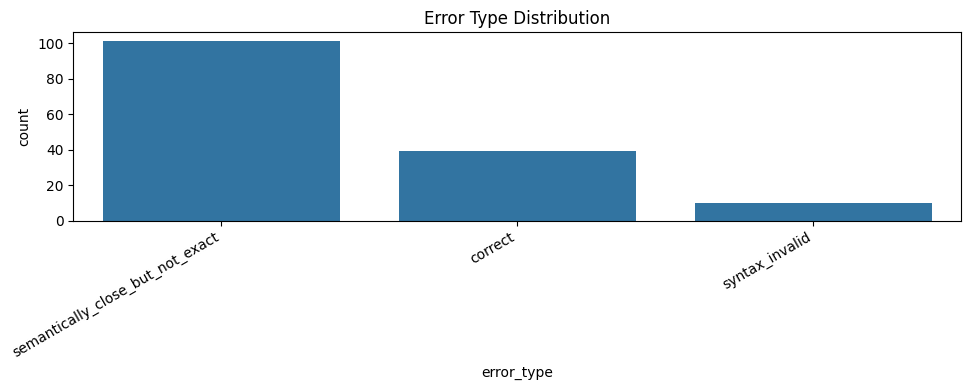

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))
sns.barplot(data=err_df, x="error_type", y="count")
plt.xticks(rotation=30, ha="right")
plt.title("Error Type Distribution")
plt.tight_layout()
plt.show()

## 5) Inspect failure cases

In [20]:
errors_csv = "results/error_analysis/errors.csv"
df_err = pd.read_csv(errors_csv)

# Show the most common non-correct errors
df_err[df_err["error_type"] != "correct"].head(20)

,intent,target_command,prediction,error_type
2,Set sFlow taceoptions to trace all events,set protocols sflow traceoptions flag all\ncommit,set protocols sflow traceoptions flag all\ncommit,semantically_close_but_not_exact
3,set a mac moving limit of 2 on vlan HR,set ethernet-switching-options secure-access-p...,set ethernet-switching-options secure-access-p...,semantically_close_but_not_exact
4,Trace the virtual chassis complete sequence nu...,set virtual-chassis traceoptions flag csn\ncommit,set virtual-chassis traceoptions flag csn\ncommit,semantically_close_but_not_exact
5,put a mac limit of 1 on interface ge-0/0/15 an...,set ethernet-switching-options secure-access-p...,set ethernet-switching-options secure-access-p...,semantically_close_but_not_exact
6,set the sflow egress sampling rate to 1000,set protocols sflow sample-rate egress 1000\nc...,set protocols sflow sample-rate egress 1000\nc...,semantically_close_but_not_exact
8,disable IGMP snooping routing information tace...,set protocols igmp-snooping traceoptions flag ...,set protocols igmp-snooping traceoptions flag ...,semantically_close_but_not_exact
9,help me configure ntp server on a juniper swit...,set system ntp server <ntp-server-address>\nco...,set system ntp server <ntp-server-address>\nc...,semantically_close_but_not_exact
10,set the SNMP VRRP notifications for the trap-g...,set snmp trap-group MONITOR-GROUP categories v...,set snmp trap-group MONITOR-GROUP categories v...,semantically_close_but_not_exact
11,How to set the RSTP maximum age of received pr...,set protocols rstp max-age <max-age-interval>\...,set protocols rstp max-age <max-age-interval>\...,semantically_close_but_not_exact
12,Enable sFlow protocol on interface ge-0/0/8,set protocols sflow interfaces ge-0/0/8\ncommit,set protocols sflow interfaces ge-0/0/8\ncommit,semantically_close_but_not_exact


## 6) Optional: per-category leaderboard view

In [21]:
per_cat = metrics.get("per_category", {})
if per_cat:
    cat_df = pd.DataFrame(per_cat).T.sort_values("normalized_exact_match", ascending=False)
    display(cat_df)
else:
    print("No category field found in predictions.")

,exact_match,normalized_exact_match,token_f1,bleu,valid_rate,entity_preservation,invalid_output_rate
,0.3,0.3,0.89834,0.79774,0.933333,0.993333,0.066667


In [22]:
import pandas as pd

# Load your most recent predictions
df = pd.read_json('/content/slm-kdn/results/predictions/predictions.jsonl', lines=True)

# Function to normalize invisible formatting
def normalize_cmd(cmd):
    if not isinstance(cmd, str): return ""
    # Convert literal '\n' strings into actual newlines
    cmd = cmd.replace('\\n', '\n')
    # Collapse any accidental double spaces into a single space
    cmd = ' '.join(cmd.split())
    return cmd.strip()

# Apply normalization
df['norm_target'] = df['target_command'].apply(normalize_cmd)
df['norm_pred'] = df['prediction'].apply(normalize_cmd)

# Calculate the TRUE Exact Match
exact_matches = (df['norm_target'] == df['norm_pred']).sum()
true_accuracy = exact_matches / len(df)

print(f"=== TRUE NORMALIZED EXACT MATCH ===")
print(f"Accuracy: {true_accuracy * 100:.2f}%\n")

# Let's peek at the real errors (like the 'show' command overfit)
real_errors = df[df['norm_target'] != df['norm_pred']][['intent', 'norm_target', 'norm_pred']]
print(f"Total Actual Errors: {len(real_errors)}")
print("\n=== TOP 5 ACTUAL ERRORS ===")
print(real_errors.head(5).to_string())

=== TRUE NORMALIZED EXACT MATCH ===
Accuracy: 94.67%

Total Actual Errors: 8

=== TOP 5 ACTUAL ERRORS ===
                                                                                             intent                                                                             norm_target                                                                                   norm_pred
46                                                                 Display igmp-snooping membership                                                          show igmp-snooping memberships                                                               show igmp-snooping membership
49        configure interface ge-0/0/0 as a part of IGMP snooping multicast group address 224.1.1.1  set protocols igmp-snooping vlan test interface ge-0/0/0 static group 224.1.1.1 commit  set protocols igmp-snooping vlan ge-0/0/0 interface ge-0/0/0 static group 224.1.1.1 commit
53                                                    

# API verification


In [23]:
import shutil
from google.colab import files
from datetime import datetime

# Zip the folder
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
filename = f'slm_kdn_backup_guardrails_{timestamp}'
shutil.make_archive(filename, 'zip', '/content/slm-kdn')

# Download it to your computer
files.download(filename + '.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>